# Face Detection & Recognition — Haar Cascade Classifier
### Detectron AI · Module 06

The live web demo uses **face-api.js** (a deep-learning face detector + 68-point
landmark + expression + age/gender network) running entirely client-side. This notebook
implements the classical predecessor — the **Viola-Jones Haar Cascade** algorithm —
which is faster, needs no GPU, and is still widely used in embedded/low-power vision
systems. It also adds simple landmark-style eye detection within each face region.


In [1]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt

def show(img, title=""):
    plt.figure(figsize=(7,7))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title); plt.axis("off"); plt.show()


## 1. Load a sample image

Using the standard 'Lenna' test image — a long-standing benchmark image in the image-processing research community.

Image shape: (512, 512, 3)


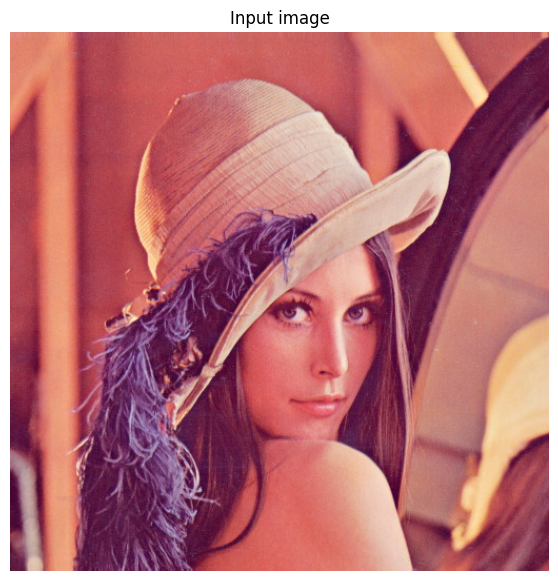

In [2]:
url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
urllib.request.urlretrieve(url, "sample_face.jpg")

img = cv2.imread("sample_face.jpg")
print("Image shape:", img.shape)
show(img, "Input image")


## 2. Load the pretrained Haar Cascade classifiers

These XML files encode boosted cascades of simple rectangular features (Viola-Jones, 2001) and ship directly with OpenCV — no separate download needed.

In [3]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


## 3. Detect faces

In [4]:
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60))
print(f"Detected {len(faces)} face(s)")
for (x, y, w, h) in faces:
    print(f"  bbox: x={x}, y={y}, w={w}, h={h}")


Detected 1 face(s)
  bbox: x=219, y=203, w=169, h=169


## 4. Detect eyes within each face region and draw overlay

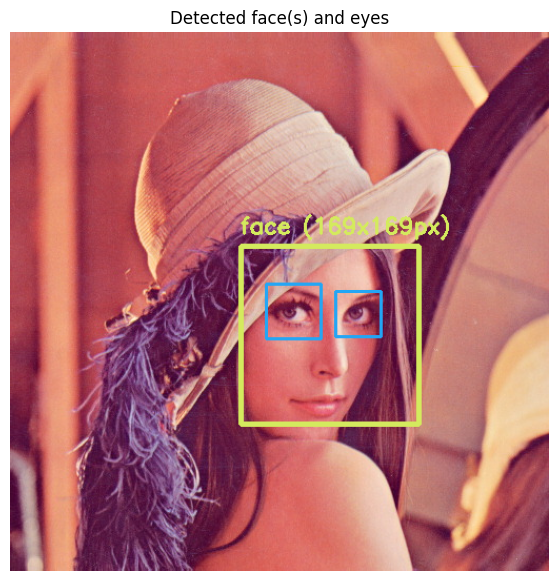

In [5]:
output = img.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(output, (x, y), (x+w, y+h), (94, 234, 212), 3)
    face_gray = gray[y:y+h, x:x+w]
    face_color = output[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(face_gray, scaleFactor=1.1, minNeighbors=8)
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(face_color, (ex, ey), (ex+ew, ey+eh), (245, 166, 35), 2)
    cv2.putText(output, f"face ({w}x{h}px)", (x, y-12), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (94, 234, 212), 2)

show(output, "Detected face(s) and eyes")


## 5. Confidence via multi-scale detection consistency

Haar cascades don't output a probability score directly, but we can estimate detection confidence by checking how consistently the face is found across nearby scale factors — a real technique used to filter false positives.

In [6]:
def detection_consistency(gray_img, scales=(1.05, 1.1, 1.15, 1.2)):
    hits = 0
    for s in scales:
        f = face_cascade.detectMultiScale(gray_img, scaleFactor=s, minNeighbors=5, minSize=(60,60))
        if len(f) > 0:
            hits += 1
    return hits / len(scales)

consistency = detection_consistency(gray)
print(f"Detection consistency across scales: {consistency:.0%}")


Detection consistency across scales: 100%


## Notes

- Haar cascades (Viola-Jones, 2001) work by sliding rectangular feature windows over
  the image at multiple scales and boosting weak classifiers (AdaBoost) into a strong
  cascade — fast enough to run in real time on a basic CPU, which is why it shipped in
  early webcams and point-and-shoot cameras.
- The live web demo's **face-api.js** pipeline (TinyFaceDetector + 68-point landmarks +
  expression net + age/gender net) is a deep-learning successor that's far more robust
  to pose, lighting, and partial occlusion, at the cost of needing a trained neural
  network rather than hand-engineered features.
